In [1]:
import awkward as ak
import matplotlib.pyplot as plt

In [9]:
Plot_dir = '/eos/user/b/bbapi/www/Analysis_plots/Background_shape_check/'

In [3]:
file1 = '/eos/user/b/bbapi/My_Analysis/2024_efficiency_study/Backgrounds/NTuples_BKG_2024_HDNA_presel_final_good_selections/merged/TTG1Jets-24SummerRun3/nominal/diphoton/CAT1_merged.parquet'
event_TTG = ak.from_parquet(file1)
file2 = '/eos/user/b/bbapi/My_Analysis/2024_efficiency_study/Backgrounds/NTuples_BKG_2024_HDNA_presel_final_good_selections/merged/TTto2L2Nu-24SummerRun3/nominal/diphoton/CAT1_merged.parquet'
event_TTto2L2Nu = ak.from_parquet(file2)
file3 = '/eos/user/b/bbapi/My_Analysis/2024_efficiency_study/Backgrounds/NTuples_BKG_2024_HDNA_presel_final_good_selections/merged/TTtoLNu2Q-24SummerRun3/nominal/diphoton/CAT1_merged.parquet'
event_TTtoLNu2Q = ak.from_parquet(file3)
file4 = '/eos/user/b/bbapi/My_Analysis/2024_efficiency_study/Backgrounds/NTuples_BKG_2024_HDNA_presel_final_good_selections/merged/WGtoLNuG-24SummerRun3/nominal/diphoton/CAT1_merged.parquet'
event_WG = ak.from_parquet(file4)

In [5]:
event_TTG.mass

<Array [204, 28.8, 70, 206, ..., 23.2, 193, 59.9, 39.1] type='14469 * ?float64'>

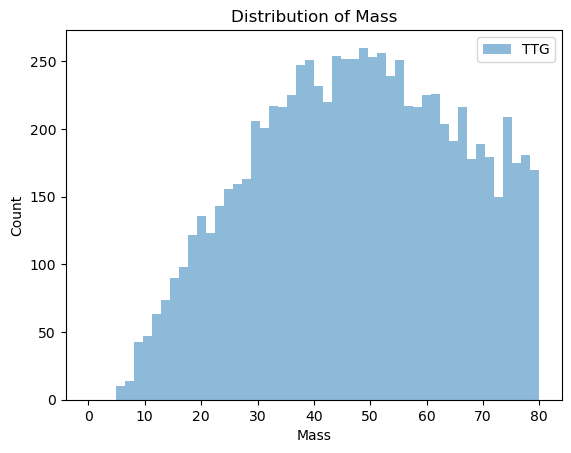

In [8]:
plt.hist(event_TTG.mass, bins=50, range = (0, 80), alpha=0.5, label='TTG')
# plt.hist(event_TTto2L2Nu.mass, bins=50, range = (0, 80), alpha=0.5, label='TTto2L2Nu')
# plt.hist(event_TTtoLNu2Q.mass, bins=50, range = (0, 80), alpha=0.5, label='TTtoLNu2Q')
# plt.hist(event_WG.mass, bins=50, range = (0, 80), alpha=0.5, label='WG')
plt.xlabel('Mass')
plt.ylabel('Count')
plt.title('Distribution of Mass')
plt.legend()
plt.show()

In [82]:
import ROOT

ROOT.gStyle.SetOptStat(111111)

def plot_1d(
    values,
    bins=50,
    x_range=(0, 80),
    label="TTG",
    color=ROOT.kBlue,
    outfile="hist.png",
    variable="Mass", 
    logy = False, 
    legend_left = False
):

    # Create histogram
    hist = ROOT.TH1F(
        "hist",
        f";{variable};Events",
        bins,
        x_range[0],
        x_range[1]
    )

    # Fill histogram
    for val in values:
        hist.Fill(val)

    # Styling
    hist.SetFillColorAlpha(color, 0.5)
    hist.SetLineColor(color)
    hist.SetLineWidth(2)

    # Canvas
    canvas = ROOT.TCanvas("canvas", "canvas", 1000, 600)

    # Leave space on right for statbox
    ROOT.gPad.SetRightMargin(0.18)

    # Draw
    if logy:
        canvas.SetLogy()
        hist.SetMinimum(0.1)  # Avoid log(0) issues
    hist.Draw("HIST")

    # Legend
    if legend_left:
        legend = ROOT.TLegend(0.12, 0.80, 0.23, 0.88)
    else:   
        legend = ROOT.TLegend(0.68, 0.80, 0.83, 0.88)
    legend.SetBorderSize(0)
    legend.SetFillStyle(0)
    legend.AddEntry(hist, label, "f")
    legend.Draw()

    # Force statbox creation
    ROOT.gPad.Update()

    # Move statbox to empty right space
    stat = hist.FindObject("stats")

    if stat:
        stat.SetX1NDC(0.83)
        stat.SetX2NDC(0.98)

        stat.SetY1NDC(0.65)
        stat.SetY2NDC(0.90)

    # Refresh
    ROOT.gPad.Modified()
    ROOT.gPad.Update()

    # Save
    canvas.SaveAs(Plot_dir + outfile)

    return hist, canvas

In [63]:
import ROOT

def plot_2d(
    x_values,
    y_values,
    x_bins=50,
    x_range=(0, 80),
    y_bins=50,
    y_range=(0, 80),
    label="TTG",
    outfile="hist2d.png",
    x_variable="X",
    y_variable="Y",
    draw_option="COLZ"
):

    # Create histogram
    hist = ROOT.TH2F(
        "hist2d",
        f"{label};{x_variable};{y_variable}",
        x_bins,
        x_range[0],
        x_range[1],
        y_bins,
        y_range[0],
        y_range[1]
    )

    # Fill histogram
    for x, y in zip(x_values, y_values):
        hist.Fill(x, y)

    # Canvas
    canvas = ROOT.TCanvas("canvas2d", "canvas2d", 1200, 700)

    # Extra space on right
    ROOT.gPad.SetRightMargin(0.28)

    # Draw
    hist.Draw(draw_option)
    hist.GetYaxis().SetTitleSize(0.055)

    # Force stat box creation
    ROOT.gPad.Update()

    # Move stat box into empty right margin
    stat = hist.FindObject("stats")

    if stat:
        stat.SetX1NDC(0.81)
        stat.SetX2NDC(0.98)

        stat.SetY1NDC(0.65)
        stat.SetY2NDC(0.90)

    # Refresh
    ROOT.gPad.Modified()
    ROOT.gPad.Update()

    # Save
    canvas.SaveAs(Plot_dir + outfile)

    return hist, canvas


In [69]:
plot_1d(event_TTG.mass, bins=50, x_range=(0,80), label="TTG1Jets", outfile="TTG1Jets_mass.png", variable = "m_{#gamma#gamma} (GeV)")
plot_1d(event_TTG.mass, bins=50, x_range=(0, 500), label="TTG1Jets", outfile="TTG1Jets_mass_full.png", variable = "m_{#gamma#gamma} (GeV)")
plot_1d(event_TTto2L2Nu.mass, bins=50, x_range=(0,80), label="TTto2L2Nu", outfile="TTto2L2Nu_mass.png", variable = "m_{#gamma#gamma} (GeV)")
plot_1d(event_TTto2L2Nu.mass, bins=50, x_range=(0, 500), label="TTto2L2Nu", outfile="TTto2L2Nu_mass_full.png", variable = "m_{#gamma#gamma} (GeV)")
plot_1d(event_TTtoLNu2Q.mass, bins=50, x_range=(0,80), label="TTtoLNu2Q", outfile="TTtoLNu2Q_mass.png", variable = "m_{#gamma#gamma} (GeV)")
plot_1d(event_TTtoLNu2Q.mass, bins=50, x_range=(0, 500), label="TTtoLNu2Q", outfile="TTtoLNu2Q_mass_full.png", variable = "m_{#gamma#gamma} (GeV)")
plot_1d(event_WG.mass, bins=50, x_range=(0,80), label="WGtoLNuG", outfile="WG_mass.png", variable = "m_{#gamma#gamma} (GeV)")
plot_1d(event_WG.mass, bins=50, x_range=(0, 500), label="WGtoLNuG", outfile="WG_mass_full.png", variable = "m_{#gamma#gamma} (GeV)")

(<cppyy.gbl.TH1F object at 0x55abcd1c0770>,
 <cppyy.gbl.TCanvas object at 0x55abccdf2a00>)

Warning in <TROOT::Append>: Replacing existing TH1: hist (Potential memory leak).
Warning in <TCanvas::Constructor>: Deleting canvas with same name: canvas
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Analysis_plots/Background_shape_check/TTG1Jets_mass.png has been created
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Analysis_plots/Background_shape_check/TTG1Jets_mass_full.png has been created
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Analysis_plots/Background_shape_check/TTto2L2Nu_mass.png has been created
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Analysis_plots/Background_shape_check/TTto2L2Nu_mass_full.png has been created
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Analysis_plots/Background_shape_check/TTtoLNu2Q_mass.png has been created
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Analysis_plots/Background_shape_check/TTtoLNu2Q_mass_full.png has been created
Info in <TCanvas::Print>: png file /eos/user/

In [72]:
plot_1d(event_TTG.pholead_pt, bins=50, x_range=(0,200), label="TTG1Jets", outfile="TTG1Jets_lead_pho_pT.png", variable = "p_{T}^{#gamma}_{lead} (GeV)")
plot_1d(event_TTto2L2Nu.pholead_pt, bins=50, x_range=(0,200), label="TTto2L2Nu", outfile="TTto2L2Nu_lead_pho_pT.png", variable = "p_{T}^{#gamma}_{lead} (GeV)")
plot_1d(event_TTtoLNu2Q.pholead_pt, bins=50, x_range=(0,200), label="TTtoLNu2Q", outfile="TTtoLNu2Q_lead_pho_pT.png", variable = "p_{T}^{#gamma}_{lead} (GeV)")
plot_1d(event_WG.pholead_pt, bins=50, x_range=(0,200), label="WGtoLNuG", outfile="WG_lead_pho_pT.png", variable = "p_{T}^{#gamma}_{lead} (GeV)")
plot_1d(event_TTG.phosublead_pt, bins=50, x_range=(0,200), label="TTG1Jets", outfile="TTG1Jets_sublead_pho_pT.png", variable = "p_{T}^{#gamma}_{sublead} (GeV)")
plot_1d(event_TTto2L2Nu.phosublead_pt, bins=50, x_range=(0,200), label="TTto2L2Nu", outfile="TTto2L2Nu_sublead_pho_pT.png", variable = "p_{T}^{#gamma}_{sublead} (GeV)")
plot_1d(event_TTtoLNu2Q.phosublead_pt, bins=50, x_range=(0,200), label="TTtoLNu2Q", outfile="TTtoLNu2Q_sublead_pho_pT.png", variable = "p_{T}^{#gamma}_{sublead} (GeV)")
plot_1d(event_WG.phosublead_pt, bins=50, x_range=(0,200), label="WGtoLNuG", outfile="WG_sublead_pho_pT.png", variable = "p_{T}^{#gamma}_{sublead} (GeV)")

plot_1d(event_TTG.pholead_pt, bins=50, x_range=(0,200), label="TTG1Jets", outfile="TTG1Jets_lead_pho_pT_logy.png", variable = "p_{T}^{#gamma}_{lead} (GeV)", logy=True)
plot_1d(event_TTto2L2Nu.pholead_pt, bins=50, x_range=(0,200), label="TTto2L2Nu", outfile="TTto2L2Nu_lead_pho_pT_logy.png", variable = "p_{T}^{#gamma}_{lead} (GeV)", logy=True)
plot_1d(event_TTtoLNu2Q.pholead_pt, bins=50, x_range=(0,200), label="TTtoLNu2Q", outfile="TTtoLNu2Q_lead_pho_pT_logy.png", variable = "p_{T}^{#gamma}_{lead} (GeV)", logy=True)
plot_1d(event_WG.pholead_pt, bins=50, x_range=(0,200), label="WGtoLNuG", outfile="WG_lead_pho_pT_logy.png", variable = "p_{T}^{#gamma}_{lead} (GeV)", logy=True)
plot_1d(event_TTG.phosublead_pt, bins=50, x_range=(0,200), label="TTG1Jets", outfile="TTG1Jets_sublead_pho_pT_logy.png", variable = "p_{T}^{#gamma}_{sublead} (GeV)", logy=True)
plot_1d(event_TTto2L2Nu.phosublead_pt, bins=50, x_range=(0,200), label="TTto2L2Nu", outfile="TTto2L2Nu_sublead_pho_pT_logy.png", variable = "p_{T}^{#gamma}_{sublead} (GeV)", logy=True)
plot_1d(event_TTtoLNu2Q.phosublead_pt, bins=50, x_range=(0,200), label="TTtoLNu2Q", outfile="TTtoLNu2Q_sublead_pho_pT_logy.png", variable = "p_{T}^{#gamma}_{sublead} (GeV)", logy=True)
plot_1d(event_WG.phosublead_pt, bins=50, x_range=(0,200), label="WGtoLNuG", outfile="WG_sublead_pho_pT_logy.png", variable = "p_{T}^{#gamma}_{sublead} (GeV)", logy=True)

(<cppyy.gbl.TH1F object at 0x55abcd23efe0>,
 <cppyy.gbl.TCanvas object at 0x55abcd114ed0>)

Warning in <TROOT::Append>: Replacing existing TH1: hist (Potential memory leak).
Warning in <TCanvas::Constructor>: Deleting canvas with same name: canvas
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Analysis_plots/Background_shape_check/TTG1Jets_lead_pho_pT.png has been created
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Analysis_plots/Background_shape_check/TTto2L2Nu_lead_pho_pT.png has been created
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Analysis_plots/Background_shape_check/TTtoLNu2Q_lead_pho_pT.png has been created
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Analysis_plots/Background_shape_check/WG_lead_pho_pT.png has been created
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Analysis_plots/Background_shape_check/TTG1Jets_sublead_pho_pT.png has been created
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Analysis_plots/Background_shape_check/TTto2L2Nu_sublead_pho_pT.png has been created
Info in <TCanvas::P

In [86]:
plot_1d((event_TTG.phosublead_pt/event_TTG.pholead_pt), bins=50, x_range=(0,1), label="TTG1Jets", outfile="TTG1Jets_pho_pT_ratio.png", variable = "p_{T}^{#gamma}_{sublead} / p_{T}^{#gamma}_{lead}", legend_left=True)
plot_1d((event_TTto2L2Nu.phosublead_pt/event_TTto2L2Nu.pholead_pt), bins=50, x_range=(0,1), label="TTto2L2Nu", outfile="TTto2L2Nu_pho_pT_ratio.png", variable = "p_{T}^{#gamma}_{sublead} / p_{T}^{#gamma}_{lead}", legend_left=True)
plot_1d((event_TTtoLNu2Q.phosublead_pt/event_TTtoLNu2Q.pholead_pt), bins=50, x_range=(0,1), label="TTtoLNu2Q", outfile="TTtoLNu2Q_pho_pT_ratio.png", variable = "p_{T}^{#gamma}_{sublead} / p_{T}^{#gamma}_{lead}", legend_left=True)
plot_1d((event_WG.phosublead_pt/event_WG.pholead_pt), bins=50, x_range=(0,1), label="WGtoLNuG", outfile="WG_pho_pT_ratio.png", variable = "p_{T}^{#gamma}_{sublead} / p_{T}^{#gamma}_{lead}", legend_left=True)

(<cppyy.gbl.TH1F object at 0x55abcd2e6e90>,
 <cppyy.gbl.TCanvas object at 0x55abcd292890>)

Warning in <TROOT::Append>: Replacing existing TH1: hist (Potential memory leak).
Warning in <TCanvas::Constructor>: Deleting canvas with same name: canvas
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Analysis_plots/Background_shape_check/TTG1Jets_pho_pT_ratio.png has been created
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Analysis_plots/Background_shape_check/TTto2L2Nu_pho_pT_ratio.png has been created
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Analysis_plots/Background_shape_check/TTtoLNu2Q_pho_pT_ratio.png has been created
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Analysis_plots/Background_shape_check/WG_pho_pT_ratio.png has been created


In [87]:
plot_2d(event_TTG.mass, (event_TTG.pholead_pt/event_TTG.mass), x_bins=50, x_range=(0,80), y_bins=50, y_range=(0,10), x_variable="m_{#gamma#gamma} [GeV]", y_variable="p_{T}^{#gamma}_{lead}/ m_{#gamma#gamma}", label="TTG1Jets",  outfile="mass_vs_ptovergamma_lead_TTG.png")
plot_2d(event_TTG.mass, (event_TTG.phosublead_pt/event_TTG.mass), x_bins=50, x_range=(0,80), y_bins=50, y_range=(0,10), x_variable="m_{#gamma#gamma} [GeV]", y_variable="p_{T}^{#gamma}_{sublead}/ m_{#gamma#gamma}", label="TTG1Jets",  outfile="mass_vs_ptovergamma_sublead_TTG.png")
plot_2d(event_TTto2L2Nu.mass, (event_TTto2L2Nu.pholead_pt/event_TTto2L2Nu.mass), x_bins=50, x_range=(0,80), y_bins=50, y_range=(0,10), x_variable="m_{#gamma#gamma} [GeV]", y_variable="p_{T}^{#gamma}_{lead}/ m_{#gamma#gamma}", label="TTto2L2Nu",  outfile="mass_vs_ptovergamma_lead_TTto2L2nu.png")
plot_2d(event_TTto2L2Nu.mass, (event_TTto2L2Nu.phosublead_pt/event_TTto2L2Nu.mass), x_bins=50, x_range=(0,80), y_bins=50, y_range=(0,10), x_variable="m_{#gamma#gamma} [GeV]", y_variable="p_{T}^{#gamma}_{sublead}/ m_{#gamma#gamma}", label="TTto2L2Nu",  outfile="mass_vs_ptovergamma_sublead_TTto2L2nu.png")
plot_2d(event_TTtoLNu2Q.mass, (event_TTtoLNu2Q.pholead_pt/event_TTtoLNu2Q.mass), x_bins=50, x_range=(0,80), y_bins=50, y_range=(0,10), x_variable="m_{#gamma#gamma} [GeV]", y_variable="p_{T}^{#gamma}_{lead}/ m_{#gamma#gamma}", label="TTtoLNu2Q",  outfile="mass_vs_ptovergamma_lead_TTtoLNu2Q.png")
plot_2d(event_TTtoLNu2Q.mass, (event_TTtoLNu2Q.phosublead_pt/event_TTtoLNu2Q.mass), x_bins=50, x_range=(0,80), y_bins=50, y_range=(0,10), x_variable="m_{#gamma#gamma} [GeV]", y_variable="p_{T}^{#gamma}_{sublead}/ m_{#gamma#gamma}", label="TTtoLNu2Q",  outfile="mass_vs_ptovergamma_sublead_TTtoLNu2Q.png")
plot_2d(event_WG.mass, (event_WG.pholead_pt/event_WG.mass), x_bins=50, x_range=(0,80), y_bins=50, y_range=(0,10), x_variable="m_{#gamma#gamma} [GeV]", y_variable="p_{T}^{#gamma}_{lead}/ m_{#gamma#gamma}", label="WGtoLNuG",  outfile="mass_vs_ptovergamma_lead_WG.png")
plot_2d(event_WG.mass, (event_WG.phosublead_pt/event_WG.mass), x_bins=50, x_range=(0,80), y_bins=50, y_range=(0,10), x_variable="m_{#gamma#gamma} [GeV]", y_variable="p_{T}^{#gamma}_{sublead}/ m_{#gamma#gamma}", label="WGtoLNuG",  outfile="mass_vs_ptovergamma_sublead_WG.png")

(<cppyy.gbl.TH2F object at 0x55abcd2452c0>,
 <cppyy.gbl.TCanvas object at 0x55abcce48c80>)

Warning in <TROOT::Append>: Replacing existing TH1: hist2d (Potential memory leak).
Warning in <TCanvas::Constructor>: Deleting canvas with same name: canvas2d
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Analysis_plots/Background_shape_check/mass_vs_ptovergamma_lead_TTG.png has been created
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Analysis_plots/Background_shape_check/mass_vs_ptovergamma_sublead_TTG.png has been created
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Analysis_plots/Background_shape_check/mass_vs_ptovergamma_lead_TTto2L2nu.png has been created
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Analysis_plots/Background_shape_check/mass_vs_ptovergamma_sublead_TTto2L2nu.png has been created
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Analysis_plots/Background_shape_check/mass_vs_ptovergamma_lead_TTtoLNu2Q.png has been created
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Analysis_plots/Background_shape_ch

In [88]:
plot_2d(event_TTG.mass, (event_TTG.phosublead_pt/event_TTG.pholead_pt), x_bins=50, x_range=(0,80), y_bins=50, y_range=(0,1), x_variable="m_{#gamma#gamma} [GeV]", y_variable="p_{T}^{#gamma}_{sublead}/ p_{T}^{#gamma}_{lead}", label="TTG1Jets",  outfile="mass_vs_pt_ratio_TTG.png")
plot_2d(event_TTto2L2Nu.mass, (event_TTto2L2Nu.phosublead_pt/event_TTto2L2Nu.pholead_pt), x_bins=50, x_range=(0,80), y_bins=50, y_range=(0,1), x_variable="m_{#gamma#gamma} [GeV]", y_variable="p_{T}^{#gamma}_{sublead}/ p_{T}^{#gamma}_{lead}", label="TTto2L2Nu",  outfile="mass_vs_pt_ratio_TTto2L2nu.png")
plot_2d(event_TTtoLNu2Q.mass, (event_TTtoLNu2Q.phosublead_pt/event_TTtoLNu2Q.pholead_pt), x_bins=50, x_range=(0,80), y_bins=50, y_range=(0,1), x_variable="m_{#gamma#gamma} [GeV]", y_variable="p_{T}^{#gamma}_{sublead}/ p_{T}^{#gamma}_{lead}", label="TTtoLNu2Q",  outfile="mass_vs_pt_ratio_TTtoLNu2Q.png")
plot_2d(event_WG.mass, (event_WG.phosublead_pt/event_WG.pholead_pt), x_bins=50, x_range=(0,80), y_bins=50, y_range=(0,1), x_variable="m_{#gamma#gamma} [GeV]", y_variable="p_{T}^{#gamma}_{sublead}/ p_{T}^{#gamma}_{lead}", label="WGtoLNuG",  outfile="mass_vs_pt_ratio_WG.png")

(<cppyy.gbl.TH2F object at 0x55abcd17d760>,
 <cppyy.gbl.TCanvas object at 0x55abcd42c130>)

Warning in <TROOT::Append>: Replacing existing TH1: hist2d (Potential memory leak).
Warning in <TCanvas::Constructor>: Deleting canvas with same name: canvas2d
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Analysis_plots/Background_shape_check/mass_vs_pt_ratio_TTG.png has been created
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Analysis_plots/Background_shape_check/mass_vs_pt_ratio_TTto2L2nu.png has been created
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Analysis_plots/Background_shape_check/mass_vs_pt_ratio_TTtoLNu2Q.png has been created
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Analysis_plots/Background_shape_check/mass_vs_pt_ratio_WG.png has been created
